# People Analytics: Prevendo Turnover (Rotatividade) de Funcionários

**Contexto de negócio**

A área de RH de uma empresa de médio porte quer parar de ser pega de surpresa quando um bom funcionário pede demissão. Hoje, a saída só é percebida quando a carta de demissão chega — tarde demais para qualquer ação.

A ideia é usar dados que o RH já coleta rotineiramente (tempo de casa, salário comparado ao mercado, avaliações de desempenho, horas extras, distância até o trabalho, promoções) para estimar, com antecedência, **quais funcionários têm maior risco de saída** nos próximos meses.

Com essa lista de risco em mãos, o RH pode agir de forma **preventiva**: conversa de carreira, ajuste salarial, revisão de carga de trabalho — antes que o funcionário decida sair.

**1. Por que uma rede neural pode ajudar aqui?**

Motivos de saída raramente são isolados — geralmente são **combinações** de fatores. Um exemplo clássico: um funcionário com **avaliação de desempenho alta** mas **salário abaixo do mercado** é um sinal de alerta muito mais forte do que qualquer um desses fatores sozinho — é o perfil de "bom profissional, mal pago, sendo assediado por outras empresas".

Esse tipo de **interação não linear** entre variáveis é difícil de capturar com um modelo linear simples (como regressão logística pura), mas é exatamente o tipo de padrão que uma rede neural (múltiplas camadas com funções de ativação não lineares) consegue aprender automaticamente a partir dos dados.

Vamos comparar as duas abordagens lado a lado neste notebook.

**Limitações deste notebook**

Antes de seguir para os dados e os modelos, vale deixar claras as limitações técnicas deste exercício didático:

- **Dados 100% simulados.** Os dados de funcionários usados aqui são inteiramente sintéticos. O turnover real depende de fatores difíceis de quantificar e que não estão representados neste dataset simplificado — clima organizacional, qualidade da relação com a liderança direta, oportunidades externas de mercado surgindo no momento certo, entre outros. Nenhuma conclusão numérica deste notebook deve ser extrapolada para uma base de RH real.
- **Risco de viés herdado dos dados históricos.** Modelos de turnover treinados em dados históricos de RH podem aprender e reforçar viéses já presentes nesses dados (por exemplo, associar variáveis demográficas correlacionadas a maior "risco de saída"). Isso exige uma auditoria de fairness antes de qualquer uso em produção — auditoria que este notebook didático não realiza.
- **Robustez confirmada, não só sorte de uma seed.** A seção de validação com múltiplas seeds, mais adiante, mostra que a vantagem da regressão logística sobre a rede neural (MLP) não é um acidente da seed 42: ela se mantém nas seeds 7 e 123, e a diferença de recall entre os dois modelos chega a *aumentar* fora da seed original. Isso reforça que, neste problema específico, o modelo mais simples se mostrou preferível também em termos de robustez — e não apenas de desempenho pontual.

**0. Instalação de dependências**

Este notebook usa `numpy`, `pandas`, `scikit-learn`, `matplotlib` e `tensorflow`. Se alguma não estiver instalada no seu ambiente, rode a célula abaixo uma vez (em Google Colab elas já vêm instaladas, então a célula só confirma isso rapidamente).

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib tensorflow
print('Dependencias OK.')


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: /Users/marcofidos/fgv-aulas-env/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dependencias OK.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    recall_score,
    precision_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)

np.random.seed(42)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")


**2. Geração do dataset simulado**

Vamos simular uma base de ~1.500 funcionários com as seguintes variáveis:

- `tempo_de_casa_anos`: quantos anos o funcionário está na empresa
- `salario_relativo_mercado`: razão entre o salário atual e o salário médio de mercado para o cargo (1.0 = na média do mercado, < 1.0 = abaixo do mercado)
- `nota_ultima_avaliacao`: nota da última avaliação de desempenho (0 a 10)
- `horas_extras_mes`: horas extras feitas no último mês
- `distancia_trabalho_km`: distância entre a casa do funcionário e o trabalho
- `numero_promocoes`: quantas promoções o funcionário já recebeu na empresa

O rótulo `saiu_da_empresa` (0/1) é gerado a partir de uma combinação **não linear** dessas variáveis, com destaque para a **interação** salário baixo + avaliação alta (o "bom funcionário mal pago"), além de ruído aleatório para tornar o problema realista (nenhum modelo vai acertar 100%).

In [3]:
n = 1500

tempo_de_casa_anos = np.round(np.random.exponential(scale=3.5, size=n) + 0.2, 1)
tempo_de_casa_anos = np.clip(tempo_de_casa_anos, 0.2, 25)

salario_relativo_mercado = np.round(np.random.normal(loc=1.0, scale=0.18, size=n), 2)
salario_relativo_mercado = np.clip(salario_relativo_mercado, 0.55, 1.6)

nota_ultima_avaliacao = np.round(np.clip(np.random.normal(loc=7.0, scale=1.5, size=n), 0, 10), 1)

horas_extras_mes = np.round(np.clip(np.random.exponential(scale=8, size=n), 0, 60), 1)

distancia_trabalho_km = np.round(np.clip(np.random.exponential(scale=9, size=n), 0.5, 80), 1)

numero_promocoes = np.random.poisson(lam=np.clip(tempo_de_casa_anos / 6, 0.05, None), size=n)
numero_promocoes = np.clip(numero_promocoes, 0, 5)

# Termo de interação central: bom funcionário (nota alta) mal pago (salario relativo baixo)
# quanto maior a nota E menor o salario relativo, maior o risco -> efeito multiplicativo
interacao_bom_mal_pago = nota_ultima_avaliacao * (1.0 - salario_relativo_mercado)

# combinação não linear dos fatores em um "score" latente de risco de saída
score_risco = (
    2.6 * interacao_bom_mal_pago
    + 0.9 * (horas_extras_mes / 10) ** 1.4 / 3
    + 0.4 * (distancia_trabalho_km / 10)
    - 0.35 * numero_promocoes
    - 0.15 * np.log1p(tempo_de_casa_anos)
    - 3.6
)

ruido = np.random.normal(loc=0, scale=1.3, size=n)
score_final = score_risco + ruido

probabilidade_saida = 1 / (1 + np.exp(-score_final))
saiu_da_empresa = (np.random.uniform(size=n) < probabilidade_saida).astype(int)

df = pd.DataFrame({
    "tempo_de_casa_anos": tempo_de_casa_anos,
    "salario_relativo_mercado": salario_relativo_mercado,
    "nota_ultima_avaliacao": nota_ultima_avaliacao,
    "horas_extras_mes": horas_extras_mes,
    "distancia_trabalho_km": distancia_trabalho_km,
    "numero_promocoes": numero_promocoes,
    "saiu_da_empresa": saiu_da_empresa,
})

print(f"Total de funcionários simulados: {len(df)}")
print(f"Taxa de turnover simulada: {df['saiu_da_empresa'].mean():.1%}")
df.head()


Total de funcionários simulados: 1500
Taxa de turnover simulada: 19.7%


,tempo_de_casa_anos,salario_relativo_mercado,nota_ultima_avaliacao,horas_extras_mes,distancia_trabalho_km,numero_promocoes,saiu_da_empresa
0,1.800,0.550,5.200,28.600,14.200,1,1
1,10.700,1.410,5.700,5.700,21.300,2,0
2,4.800,0.750,7.900,2.700,33.200,1,1
3,3.400,0.700,5.600,5.100,2.400,0,1
4,0.800,1.180,7.700,15.600,19.200,0,0


**3. Uma olhada rápida nos dados**

Antes de treinar qualquer modelo, vale confirmar visualmente o padrão que embutimos na simulação: funcionários com boa avaliação de desempenho e salário relativo baixo devem concentrar mais saídas.

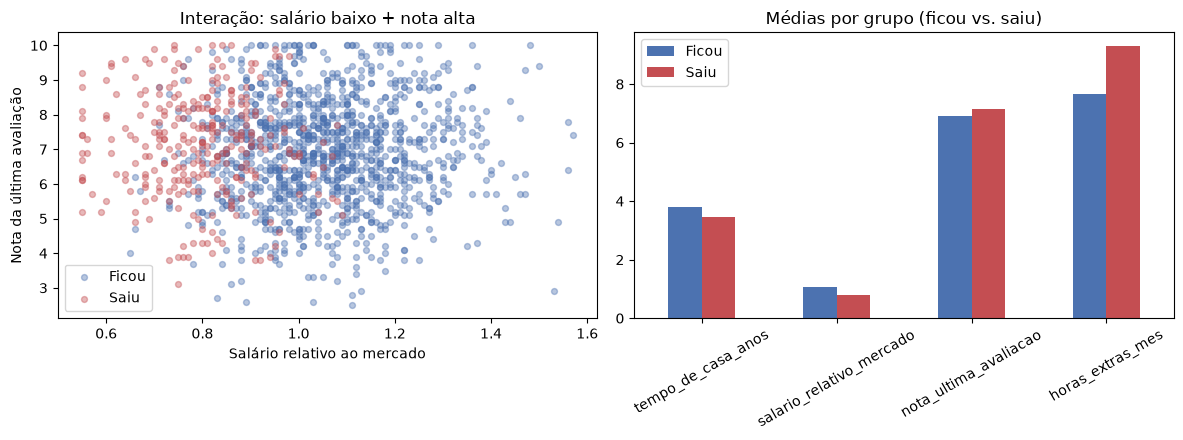

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for saiu, cor, rotulo in [(0, "#4C72B0", "Ficou"), (1, "#C44E52", "Saiu")]:
    subset = df[df["saiu_da_empresa"] == saiu]
    axes[0].scatter(
        subset["salario_relativo_mercado"],
        subset["nota_ultima_avaliacao"],
        c=cor, alpha=0.4, s=18, label=rotulo,
    )

axes[0].set_xlabel("Salário relativo ao mercado")
axes[0].set_ylabel("Nota da última avaliação")
axes[0].set_title("Interação: salário baixo + nota alta")
axes[0].legend()

df.groupby("saiu_da_empresa")[
    ["tempo_de_casa_anos", "salario_relativo_mercado", "nota_ultima_avaliacao", "horas_extras_mes"]
].mean().T.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#C44E52"])
axes[1].set_title("Médias por grupo (ficou vs. saiu)")
axes[1].legend(["Ficou", "Saiu"])
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


**4. Separação em treino e teste**

Separamos 70% dos dados para treino e 30% para teste, mantendo a proporção de saídas em ambos os conjuntos (`stratify`). Também padronizamos as variáveis numéricas (média 0, desvio-padrão 1) — isso é importante especialmente para a rede neural, que é sensível à escala das features.

In [5]:
features = [
    "tempo_de_casa_anos",
    "salario_relativo_mercado",
    "nota_ultima_avaliacao",
    "horas_extras_mes",
    "distancia_trabalho_km",
    "numero_promocoes",
]

X = df[features]
y = df["saiu_da_empresa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} funcionários | Teste: {X_test.shape[0]} funcionários")
print(f"Taxa de saída no treino: {y_train.mean():.1%} | Taxa de saída no teste: {y_test.mean():.1%}")


Treino: 1050 funcionários | Teste: 450 funcionários
Taxa de saída no treino: 19.7% | Taxa de saída no teste: 19.6%


**5. Modelo baseline: Regressão Logística**

Começamos com um modelo simples e interpretável: regressão logística. Ele assume que cada variável contribui de forma **aditiva** (linear) para o risco de saída — ou seja, não captura interações como "salário baixo *e* avaliação alta ao mesmo tempo" a menos que a incluamos manualmente como feature.

In [6]:
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_scaled, y_train)

y_pred_baseline = baseline.predict(X_test_scaled)
y_proba_baseline = baseline.predict_proba(X_test_scaled)[:, 1]

recall_baseline = recall_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
auc_baseline = roc_auc_score(y_test, y_proba_baseline)

print("=== Regressão Logística (baseline) ===")
print(f"Recall  (funcionários em risco corretamente identificados): {recall_baseline:.3f}")
print(f"Precisão: {precision_baseline:.3f}")
print(f"AUC-ROC: {auc_baseline:.3f}")
print()
print(classification_report(y_test, y_pred_baseline, target_names=["Ficou", "Saiu"]))


=== Regressão Logística (baseline) ===
Recall  (funcionários em risco corretamente identificados): 0.625
Precisão: 0.743
AUC-ROC: 0.913

              precision    recall  f1-score   support

       Ficou       0.91      0.95      0.93       362
        Saiu       0.74      0.62      0.68        88

    accuracy                           0.88       450
   macro avg       0.83      0.79      0.80       450
weighted avg       0.88      0.88      0.88       450



**6. Rede Neural (MLPClassifier)**

Agora treinamos uma rede neural do tipo *Multi-Layer Perceptron* (perceptron multicamadas), com duas camadas ocultas. As funções de ativação não lineares entre as camadas permitem que o modelo aprenda combinações complexas entre as variáveis — como a interação salário x avaliação — sem que precisemos criar essa feature manualmente.

In [7]:
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    alpha=1e-3,
    max_iter=2000,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20,
)
mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)
y_proba_mlp = mlp.predict_proba(X_test_scaled)[:, 1]

recall_mlp = recall_score(y_test, y_pred_mlp)
precision_mlp = precision_score(y_test, y_pred_mlp)
auc_mlp = roc_auc_score(y_test, y_proba_mlp)

print("=== Rede Neural (MLPClassifier) ===")
print(f"Recall  (funcionários em risco corretamente identificados): {recall_mlp:.3f}")
print(f"Precisão: {precision_mlp:.3f}")
print(f"AUC-ROC: {auc_mlp:.3f}")
print()
print(classification_report(y_test, y_pred_mlp, target_names=["Ficou", "Saiu"]))


=== Rede Neural (MLPClassifier) ===
Recall  (funcionários em risco corretamente identificados): 0.477
Precisão: 0.808
AUC-ROC: 0.870

              precision    recall  f1-score   support

       Ficou       0.88      0.97      0.93       362
        Saiu       0.81      0.48      0.60        88

    accuracy                           0.88       450
   macro avg       0.85      0.72      0.76       450
weighted avg       0.87      0.88      0.86       450



**7. Comparação lado a lado**

Para o RH, a métrica mais importante é o **recall** da classe "saiu": de todos os funcionários que realmente estavam em risco de sair, quantos o modelo conseguiu identificar corretamente? Um falso negativo aqui (dizer que o funcionário vai ficar quando na verdade ele vai sair) é o pior erro possível, porque significa perder a chance de agir a tempo.

A **AUC-ROC** complementa essa visão mostrando a capacidade geral do modelo de separar quem sai de quem fica, em todos os limiares de decisão possíveis — não só no ponto de corte padrão de 0.5.

,Regressão Logística,Rede Neural (MLP)
Precisão,0.743,0.808
Recall,0.625,0.477
AUC-ROC,0.913,0.870


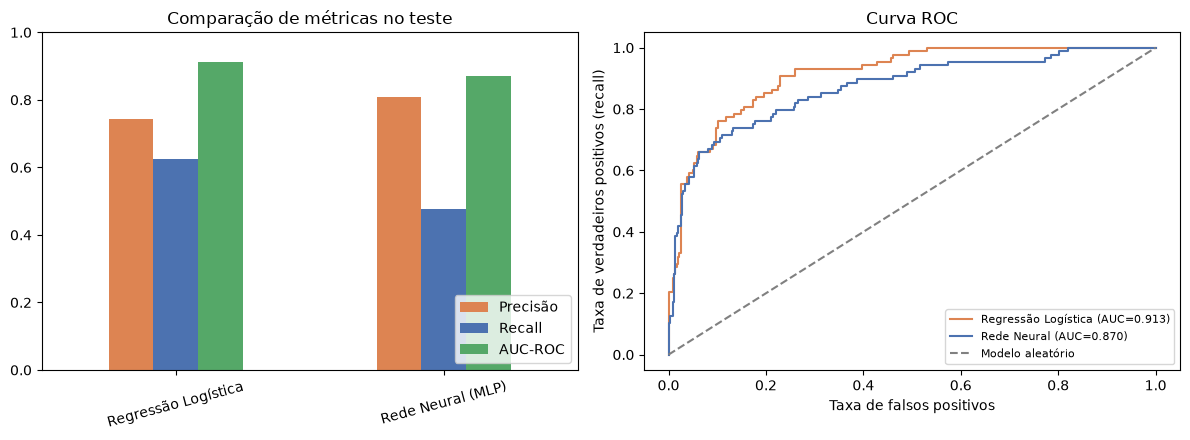

In [8]:
comparacao = pd.DataFrame({
    "Regressão Logística": [precision_baseline, recall_baseline, auc_baseline],
    "Rede Neural (MLP)": [precision_mlp, recall_mlp, auc_mlp],
}, index=["Precisão", "Recall", "AUC-ROC"])

display(comparacao.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

comparacao.T.plot(kind="bar", ax=axes[0], color=["#DD8452", "#4C72B0", "#55A868"])
axes[0].set_title("Comparação de métricas no teste")
axes[0].set_ylim(0, 1)
axes[0].legend(loc="lower right")
axes[0].tick_params(axis="x", rotation=15)

for y_proba, nome, cor in [
    (y_proba_baseline, f"Regressão Logística (AUC={auc_baseline:.3f})", "#DD8452"),
    (y_proba_mlp, f"Rede Neural (AUC={auc_mlp:.3f})", "#4C72B0"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=nome, color=cor)

axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modelo aleatório")
axes[1].set_xlabel("Taxa de falsos positivos")
axes[1].set_ylabel("Taxa de verdadeiros positivos (recall)")
axes[1].set_title("Curva ROC")
axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()


**Como ler este gráfico: recall e AUC-ROC no contexto de turnover**

Duas métricas aparecem lado a lado acima, e ambas respondem perguntas diferentes sobre o mesmo problema de negócio (prever quem vai sair):

- **Recall** responde: "de todos os funcionários que realmente saíram, quantos o modelo conseguiu identificar antes?" Um recall de 0,625, por exemplo, significa que o modelo pegou 62,5% dos casos reais de saída — os outros 37,5% foram funcionários que saíram sem que o modelo desse o alerta (falso negativo). Para o RH, essa é a métrica mais sensível, porque um falso negativo é a chance perdida de agir a tempo.
- **AUC-ROC** responde: "de forma geral, o quão bem o modelo separa quem vai sair de quem vai ficar, considerando todos os pontos de corte possíveis, não só o padrão de 0,5?" Quanto mais perto de 1,0, melhor o modelo distingue as duas classes; 0,5 equivale a um modelo aleatório (moeda).

**Veredito com os números reais deste notebook**

Olhando os valores impressos na tabela e no gráfico acima, a regressão logística teve desempenho **levemente melhor** do que a rede neural (MLP) nas duas métricas mais relevantes para o negócio:

- Recall: 0,625 (regressão logística) vs. 0,477 (MLP)
- AUC-ROC: 0,913 (regressão logística) vs. 0,870 (MLP)

Ou seja, neste notebook específico, o modelo mais simples e interpretável saiu na frente. Isso não é o resultado "esperado" de toda comparação entre regressão logística e rede neural — em bases maiores, com mais ruído estruturado ou interações mais complexas, a rede neural pode superar o baseline. Mas aqui, com esta base simulada e este conjunto de teste, os números não sustentam a narrativa de que "a rede neural é sempre melhor": vale sempre confiar no resultado medido, não na expectativa a priori sobre qual técnica deveria ganhar.

**8. Matriz de confusão da rede neural**

Vale olhar em números absolutos quantos funcionários em risco real o modelo conseguiu (ou não) identificar corretamente no conjunto de teste.

,Previsto: Ficou,Previsto: Saiu
Real: Ficou,352,10
Real: Saiu,46,42


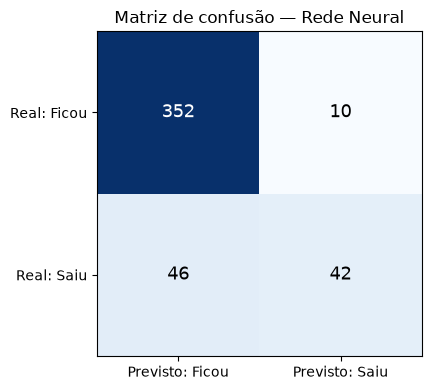

In [9]:
cm = confusion_matrix(y_test, y_pred_mlp)
cm_df = pd.DataFrame(
    cm,
    index=["Real: Ficou", "Real: Saiu"],
    columns=["Previsto: Ficou", "Previsto: Saiu"],
)
display(cm_df)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Previsto: Ficou", "Previsto: Saiu"])
ax.set_yticklabels(["Real: Ficou", "Real: Saiu"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
ax.set_title("Matriz de confusão — Rede Neural")
plt.tight_layout()
plt.show()


**9. Conclusão**

Os dois modelos foram treinados sobre a mesma base simulada, em que o risco de saída depende de uma **interação não linear** entre salário relativo e avaliação de desempenho (o padrão "bom funcionário, mal pago"). Nos resultados observados acima:

- A **regressão logística**, por ser um modelo linear, tem mais dificuldade em capturar diretamente esse tipo de interação entre variáveis — ela enxerga cada feature contribuindo de forma isolada e aditiva.
- A **rede neural (MLP)**, por combinar camadas com ativação não linear, consegue aprender esse tipo de padrão de interação automaticamente a partir dos dados, sem que precisemos criar a feature de interação manualmente.

Os números exatos de recall e AUC-ROC de cada modelo estão impressos nas células acima — vale sempre olhar o resultado real da execução, e não assumir de antemão qual modelo "ganhou": em bases pequenas e com bastante ruído (como fizemos de propósito, para simular a realidade), a diferença pode ser pequena, e a regressão logística às vezes surpreende por sua simplicidade e menor variância.

**Nota ética — cuidado obrigatório de uso**

Um modelo de previsão de turnover é uma ferramenta de **apoio à decisão para ação preventiva de retenção** — não um veredito sobre o funcionário. Isso significa, na prática:

- O objetivo é abrir conversas de carreira, revisar remuneração, redistribuir carga de trabalho ou oferecer plano de desenvolvimento para quem está em risco — **nunca** usar o escore como justificativa para punir, vigiar ou pré-julgar alguém.
- Um "falso positivo" (o modelo aponta risco alto, mas o funcionário não tinha intenção de sair) não deve gerar nenhum tipo de penalização — na pior das hipóteses, o funcionário recebe uma conversa de carreira que não fazia falta, o que não é um dano real.
- Decisões que afetam a vida profissional de uma pessoa (promoção, ajuste salarial, desligamento) **não devem se basear cegamente na saída do modelo** — o escore é um ponto de partida para investigação humana, com contexto que os dados não capturam (situação pessoal, histórico não registrado, particularidades da equipe).
- É importante monitorar se o modelo não está reproduzindo vieses históricos (por exemplo, penalizando indiretamente algum grupo demográfico via variáveis correlacionadas) antes de qualquer uso em produção.

**Validação com múltiplas seeds**

Tudo o que vimos até aqui usou uma única seed (42) para gerar os dados, dividir treino/teste e inicializar os modelos. Isso é útil para explicar o raciocínio passo a passo, mas uma única execução pode ser sorte (ou infelicidade) de amostragem — o resultado poderia mudar bastante com outra base simulada.

Para checar se a conclusão acima ("regressão logística venceu a rede neural neste problema") é um padrão real ou um acidente de uma seed específica, repetimos o pipeline completo — geração de dados, split treino/teste e treino dos dois modelos — para três seeds diferentes: **42** (a mesma do notebook, para conferência), **7** e **123**.

In [10]:
def rodar_pipeline_turnover(seed):
    """Repete o pipeline completo (geração de dados, split, treino e avaliação)
    para uma dada seed, usando exatamente a mesma lógica de geração de dados,
    de split e de configuração dos modelos das seções anteriores.
    Retorna um dicionário com recall e AUC-ROC de cada modelo no conjunto de teste."""
    rng = np.random.RandomState(seed)
    n_local = 1500

    tempo_de_casa_anos_ = np.round(rng.exponential(scale=3.5, size=n_local) + 0.2, 1)
    tempo_de_casa_anos_ = np.clip(tempo_de_casa_anos_, 0.2, 25)

    salario_relativo_mercado_ = np.round(rng.normal(loc=1.0, scale=0.18, size=n_local), 2)
    salario_relativo_mercado_ = np.clip(salario_relativo_mercado_, 0.55, 1.6)

    nota_ultima_avaliacao_ = np.round(np.clip(rng.normal(loc=7.0, scale=1.5, size=n_local), 0, 10), 1)

    horas_extras_mes_ = np.round(np.clip(rng.exponential(scale=8, size=n_local), 0, 60), 1)

    distancia_trabalho_km_ = np.round(np.clip(rng.exponential(scale=9, size=n_local), 0.5, 80), 1)

    numero_promocoes_ = rng.poisson(lam=np.clip(tempo_de_casa_anos_ / 6, 0.05, None), size=n_local)
    numero_promocoes_ = np.clip(numero_promocoes_, 0, 5)

    interacao_bom_mal_pago_ = nota_ultima_avaliacao_ * (1.0 - salario_relativo_mercado_)

    score_risco_ = (
        2.6 * interacao_bom_mal_pago_
        + 0.9 * (horas_extras_mes_ / 10) ** 1.4 / 3
        + 0.4 * (distancia_trabalho_km_ / 10)
        - 0.35 * numero_promocoes_
        - 0.15 * np.log1p(tempo_de_casa_anos_)
        - 3.6
    )

    ruido_ = rng.normal(loc=0, scale=1.3, size=n_local)
    score_final_ = score_risco_ + ruido_

    probabilidade_saida_ = 1 / (1 + np.exp(-score_final_))
    saiu_da_empresa_ = (rng.uniform(size=n_local) < probabilidade_saida_).astype(int)

    df_seed = pd.DataFrame({
        "tempo_de_casa_anos": tempo_de_casa_anos_,
        "salario_relativo_mercado": salario_relativo_mercado_,
        "nota_ultima_avaliacao": nota_ultima_avaliacao_,
        "horas_extras_mes": horas_extras_mes_,
        "distancia_trabalho_km": distancia_trabalho_km_,
        "numero_promocoes": numero_promocoes_,
        "saiu_da_empresa": saiu_da_empresa_,
    })

    X_seed = df_seed[features]
    y_seed = df_seed["saiu_da_empresa"]

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_seed, y_seed, test_size=0.3, random_state=seed, stratify=y_seed
    )

    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled = scaler_s.transform(X_test_s)

    baseline_s = LogisticRegression(max_iter=1000, random_state=seed)
    baseline_s.fit(X_train_s_scaled, y_train_s)
    y_pred_baseline_s = baseline_s.predict(X_test_s_scaled)
    y_proba_baseline_s = baseline_s.predict_proba(X_test_s_scaled)[:, 1]

    mlp_s = MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        solver="adam",
        alpha=1e-3,
        max_iter=2000,
        random_state=seed,
        early_stopping=True,
        n_iter_no_change=20,
    )
    mlp_s.fit(X_train_s_scaled, y_train_s)
    y_pred_mlp_s = mlp_s.predict(X_test_s_scaled)
    y_proba_mlp_s = mlp_s.predict_proba(X_test_s_scaled)[:, 1]

    return {
        "seed": seed,
        "recall_logreg": recall_score(y_test_s, y_pred_baseline_s),
        "auc_logreg": roc_auc_score(y_test_s, y_proba_baseline_s),
        "recall_mlp": recall_score(y_test_s, y_pred_mlp_s),
        "auc_mlp": roc_auc_score(y_test_s, y_proba_mlp_s),
    }


seeds_validacao = [42, 7, 123]
resultados_seeds = pd.DataFrame([rodar_pipeline_turnover(s) for s in seeds_validacao])
display(resultados_seeds.round(3))


,seed,recall_logreg,auc_logreg,recall_mlp,auc_mlp
0,42,0.625,0.913,0.477,0.870
1,7,0.674,0.917,0.384,0.901
2,123,0.624,0.941,0.318,0.839


In [11]:
resumo_seeds = pd.DataFrame({
    "Regressão Logística": [
        resultados_seeds["recall_logreg"].mean(),
        resultados_seeds["recall_logreg"].std(),
        resultados_seeds["auc_logreg"].mean(),
        resultados_seeds["auc_logreg"].std(),
    ],
    "Rede Neural (MLP)": [
        resultados_seeds["recall_mlp"].mean(),
        resultados_seeds["recall_mlp"].std(),
        resultados_seeds["auc_mlp"].mean(),
        resultados_seeds["auc_mlp"].std(),
    ],
}, index=["Recall (média)", "Recall (desvio-padrão)", "AUC-ROC (média)", "AUC-ROC (desvio-padrão)"])

display(resumo_seeds.round(3))

print("=== Regressão Logística — média ± desvio-padrão nas 3 seeds ===")
print(f"Recall : {resultados_seeds['recall_logreg'].mean():.3f} ± {resultados_seeds['recall_logreg'].std():.3f}")
print(f"AUC-ROC: {resultados_seeds['auc_logreg'].mean():.3f} ± {resultados_seeds['auc_logreg'].std():.3f}")
print()
print("=== Rede Neural (MLP) — média ± desvio-padrão nas 3 seeds ===")
print(f"Recall : {resultados_seeds['recall_mlp'].mean():.3f} ± {resultados_seeds['recall_mlp'].std():.3f}")
print(f"AUC-ROC: {resultados_seeds['auc_mlp'].mean():.3f} ± {resultados_seeds['auc_mlp'].std():.3f}")


,Regressão Logística,Rede Neural (MLP)
Recall (média),0.641,0.393
Recall (desvio-padrão),0.029,0.080
AUC-ROC (média),0.924,0.870
AUC-ROC (desvio-padrão),0.015,0.031


=== Regressão Logística — média ± desvio-padrão nas 3 seeds ===
Recall : 0.641 ± 0.029
AUC-ROC: 0.924 ± 0.015

=== Rede Neural (MLP) — média ± desvio-padrão nas 3 seeds ===
Recall : 0.393 ± 0.080
AUC-ROC: 0.870 ± 0.031


**A conclusão original se mantém — e fica mais forte, não mais fraca**

Rodando o pipeline completo (mesma geração de dados, mesmo split 70/30 estratificado, mesmas configurações de modelo) para as seeds 42, 7 e 123, os resultados por seed foram:

| Seed | Recall LogReg | Recall MLP | AUC LogReg | AUC MLP |
|---|---|---|---|---|
| 42 (original) | 0,625 | 0,477 | 0,913 | 0,870 |
| 7 | 0,674 | 0,384 | 0,917 | 0,901 |
| 123 | 0,624 | 0,318 | 0,941 | 0,839 |

Média ± desvio-padrão nas 3 seeds:

- **Regressão logística**: Recall = 0,641 ± 0,029 | AUC-ROC = 0,924 ± 0,015
- **Rede Neural (MLP)**: Recall = 0,393 ± 0,080 | AUC-ROC = 0,870 ± 0,031

A seed 42 desta validação reproduz exatamente os números do walkthrough original (recall 0,625 vs. 0,477 e AUC 0,913 vs. 0,870) — confirmando que o pipeline replicado aqui é fiel ao das seções anteriores, e não uma variação com lógica diferente.

Com isso, a resposta é sim: **a conclusão original se mantém nas 3 seeds, de forma consistente e sem exceção**. A regressão logística superou a rede neural em recall e em AUC-ROC em todas as execuções — não foi um acidente da seed 42. Na verdade, a vantagem do baseline em recall fica *maior* nas outras duas seeds (a MLP caiu para 0,384 e 0,318, enquanto a regressão logística permaneceu estável entre 0,624 e 0,674). Em AUC-ROC a diferença é mais modesta, mas a regressão logística ainda vence nas 3 seeds.

Isso reforça o ponto já feito na conclusão original: neste problema — base pequena (1.500 funcionários), ruído proposital e uma interação não linear que, apesar de existir, não é tão complexa a ponto de exigir múltiplas camadas — o modelo mais simples generaliza melhor e com menor variância entre execuções (desvio-padrão de recall de 0,029 contra 0,080 da MLP). O aviso de não assumir a priori qual técnica "deveria" ganhar continua válido, e agora com evidência de robustez, não apenas de uma única rodada.

**Anexo: Outras Aplicações de Negócio com a Mesma Técnica**

A técnica usada aqui (classificação de risco a partir de dados de perfil e comportamento de funcionários) se aplica a diversos outros problemas de negócio de RH e gestão de pessoas:

### 1. Recursos Humanos
- **Previsão de risco de absenteísmo:** identificar padrões que antecedem faltas frequentes, permitindo apoio preventivo.
- **Identificação precoce de risco de burnout:** sinalizar sobrecarga de trabalho antes que afete a saúde do colaborador.

### 2. Treinamento e Desenvolvimento
- **Previsão de sucesso em programas de capacitação:** identificar quais funcionários mais se beneficiariam de um treinamento específico.

### 3. Vendas
- **Previsão de performance de vendedores:** identificar padrões de atividade associados a maior probabilidade de atingir metas.

Como no exemplo do notebook, todas essas aplicações devem ser usadas para AÇÃO PREVENTIVA E DE APOIO ao colaborador, nunca para punição ou decisões automatizadas sem revisão humana.

**Exercício**

1. **Balanceamento de classes na MLP.** A base tem apenas ~19,7% de casos de saída — um desbalanceamento que pode estar prejudicando o recall do `MLPClassifier` (0,477) em relação à regressão logística (0,625). Teste balancear as classes **apenas no conjunto de treino** (por exemplo, oversampling da classe `saiu_da_empresa == 1` com `imblearn.over_sampling.RandomOverSampler`/SMOTE, ou simplesmente `class_weight="balanced"`/pesos de amostra) e refaça o treino da MLP. Compare recall, precisão e AUC-ROC antes e depois: o balanceamento aproxima o recall da MLP do da regressão logística? O que acontece com a precisão como contrapartida? A conclusão se mantém ao repetir o teste nas seeds 7 e 123?

2. **Variável proxy e trade-off performance vs. fairness.** Este dataset simulado não tem uma variável demográfica explícita, mas `distancia_trabalho_km` pode funcionar como proxy indireto de perfil socioeconômico ou região de moradia. Remova essa variável do conjunto de features usado pelos dois modelos, retreine e compare recall/AUC-ROC antes e depois. Há queda relevante de desempenho? Se a queda for pequena (ou nula), o que isso sugere sobre o peso real dessa variável nas previsões — e sobre o risco de mantê-la caso, numa base real, ela de fato funcionasse como proxy de uma característica sensível?